## Evaluating modelled CA1 activity on a linear track

Basic version:
* Linear track (approx 5 runs)
* CA3: 8 preset place fields
* CA1: 
  * Receives reward signal at the dendrites
  * Local learning
  * (1) 1 cell => (2) population with lateral inhibition

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm

import ratinabox 
from ratinabox import Environment
from ratinabox.Neurons import PlaceCells

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, util

In [2]:
warnings.filterwarnings("ignore", message="Warning: You have solid 1D boundary", category=UserWarning)

In [3]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(util)

<module 'predhpc.util' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/util.py'>

## Define some functions

In [50]:
def plot_environment(Ag):
    fig, ax = Ag.Environment.plot_environment()
    ax.plot(Ag.start_pos, 0, marker="o", color="blue", zorder=5)
    ax.plot(Ag.reset_pos, 0, marker="x", color="red", zorder=5)
    ax.set_title("Environment")

def plot_place_weights(CA1, CA3s_PC):
    fig, ax = plt.subplots(figsize=(3, 1.5))
    ax.plot(CA3s_PC.place_cell_centres[:, 0], CA1.inputs["PlaceCells"]["w"][0], color=CA1.color)
    ax.set_xlabel("Input place cell center / m")
    ax.set_ylabel("Weights")
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title("Input place cell center weights")
    
def plot_all_place_weights(CA1_weights, CA3s_PC, cmap="crest"):
    CA1_weights = np.asarray(CA1_weights) # epochs x num inputs
    cmap_vals = np.linspace(0, 1, len(CA1_weights))
    colors = sns.color_palette(cmap, as_cmap=True)(cmap_vals)
    alpha = 0.8 ** (len(colors) / 6)
    
    fig, ax = plt.subplots(figsize=(5, 3))
    for i, color in enumerate(colors):
        label = None
        if i == 0:
            label = "first"
        elif i == len(colors) - 1:
            label = "last"
        ax.plot(CA3s_PC.place_cell_centres[:, 0], CA1_weights[i], color=color, alpha=alpha, label=label)
    
    ax.legend()
    ax.set_xlabel("Input place cell center / m")
    ax.set_ylabel("Weights")
    ax.spines[['top', 'right']].set_visible(False) 
    ax.set_title("Input weights across learning")
    
class handle_1D_place_cell_centres(): # handle an error in place center plotting for 1D place cells
    def __init__(self, PCs):
        self.PCs = PCs
        self.PCs.place_cell_centres =  np.pad(self.PCs.place_cell_centres, ((0, 0), (0, 1)))
    def __enter__(self):
        return
    def __exit__(self, type, value, traceback):
        self.PCs.place_cell_centres =  self.PCs.place_cell_centres[:, :1]
        

def learn(env_params, agent_params, CA3_PC_params, CA1_params, reward_lr_fact=3, num_rwd=200):
    
    names = ["NUM_CA3", "CA1_LR", "CA1_OJA", "RWD_LR_FACT", "NUM_RWD"]
    values = [CA3_PC_params["n"], CA1_params["lr"], CA1_params["oja"], reward_lr_fact, num_rwd]
    print_vals = [f"{name}: {value}" for name, value in zip(names, values)]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env = Environment(params=env_params)
    Ag = agent.ResetAgent(Env, params=agent_params)
    CA3s_PC = PlaceCells(Ag, params=CA3_PC_params)

    CA1_params["input_layers"] = [CA3s_PC]
    CA1 = neurons.HebbianLayer(Ag, params=CA1_params)
    plot_environment(Ag)

    # plot CA3 properties
    with handle_1D_place_cell_centres(CA3s_PC):
        fig, ax = CA3s_PC.plot_place_cell_locations()
    ax.set_title("CA3 place cell locations")
    fig, ax = plt.subplots(figsize=(3, 1.5))
    CA3s_PC.plot_rate_map(chosen_neurons="all", fig=fig, ax=ax)
    ax.set_title("CA3 rate map")
    
    # run learning
    CA1_weights = [CA1.inputs["PlaceCells"]["w"][0].copy()]
    for i in tqdm(range(3600)):
        Ag.update()
        CA3s_PC.update()

        lr_fact = 1
        if Ag.check_reset_pos():
            lr_fact = reward_lr_fact
        CA1.update(lr_fact=lr_fact)
        if not i % 100:
            CA1_weights.append(CA1.inputs["PlaceCells"]["w"][0].copy())

        if len(Ag.reached_reset_pos) >= num_rwd:
            break

    plot_all_place_weights(CA1_weights, CA3s_PC)

    fig, ax = plt.subplots(figsize=(3, 1.5))
    t_start = min(i - i // 10, i - 200)
    CA1.plot_rate_map(chosen_neurons="all", fig=fig, ax=ax, t_start=t_start)
    ax.set_title("CA1 rate map (final 10% of steps, min. 200)")

    fig, ax = Ag.plot_trajectory_resets(framerate=1/Ag.dt)
    ax.set_title("Trajectories")

    fig, ax = plt.subplots(figsize=(4, 1.5))
    CA1.plot_rate_timeseries(chosen_neurons="all", spikes=True, fig=fig, ax=ax)
    ax.set_title("CA1 rate timeseries")
    
    fig, ax = plt.subplots(figsize=(4, 1.5))
    CA3s_PC.plot_rate_timeseries(chosen_neurons="all", spikes=True, fig=fig, ax=ax)
    ax.set_title("CA3 rate timeseries")

## Set hyperparameters

In [51]:
env_params = {
    "dimensionality": "1D",
    "scale": 1,
}

dt = 0.02
agent_params = {
    "reset_tolerance_prop": 0.8,
    "dt": 0.02,
    "speed_mean": 1, # sets directionality
    "speed_std": 0.5, 
    "start_pos": 0 + dt,
    "reset_pos": env_params["scale"] - dt,
    "fixed_direction": True,
}

CA3_PC_params = {
    "description": "gaussian_threshold",
    "min_fr": 0,
    "max_fr": 1,
    "color": "C1",
    "widths": agent_params["dt"] * 4,
}

CA1_params = {
    "n": 1,
    "name": "CA1Hebb",
    "color": "C2",
    "biases": np.zeros(1),
    "init_weights_zero": True,
}

In [52]:
NUM_CA3 = 8

CA1_LR = 5e-4
CA1_OJA = True

RWD_LR_FACT = 100
NUM_RWD = 1000

CA3_PC_params["n"] = NUM_CA3
CA1_params["lr"] = CA1_LR
CA1_params["oja"] = CA1_OJA

NUM_CA3: 8
CA1_LR: 0.0005
CA1_OJA: True
RWD_LR_FACT: 100
NUM_RWD: 1000

Warning you have solid 1D boundary conditions and non-zero speed mean. 
Warning you have solid 1D boundary conditions and non-zero speed mean. 


100%|█████████████████████████████████████| 3600/3600 [00:01<00:00, 3493.40it/s]


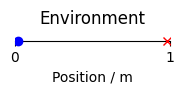

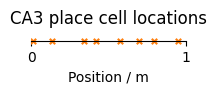

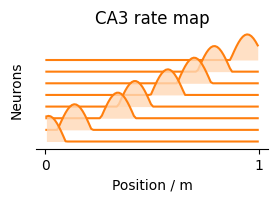

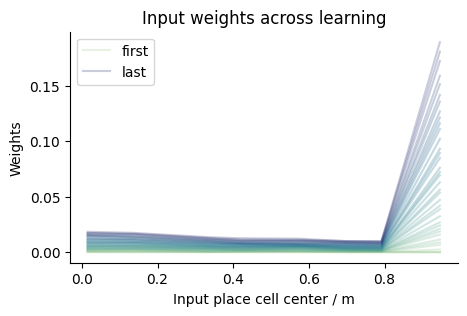

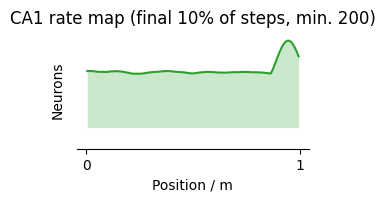

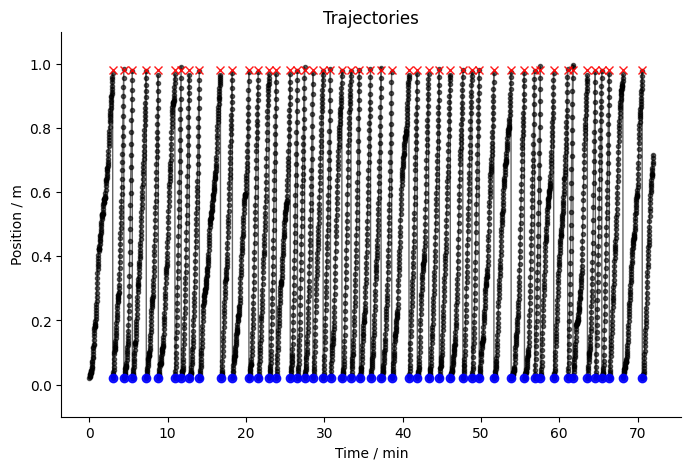

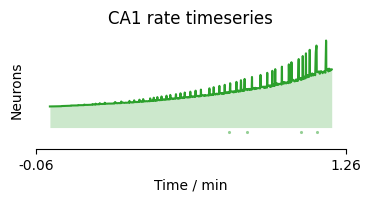

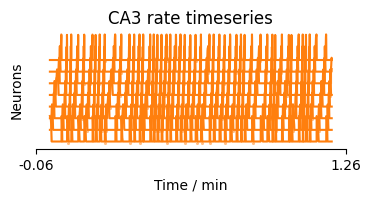

In [53]:
learn(
    env_params, 
    agent_params, 
    CA3_PC_params, 
    CA1_params, 
    reward_lr_fact=RWD_LR_FACT, 
    num_rwd=NUM_RWD, 
)